# Stage 4 — Comparison: PMI Codebook vs AI Encoder/Decoder

This notebook compares two CSI-feedback approaches on the **same channel**, plotting
**SGCS vs feedback report length (bits)**:

| Approach | Description |
|---|---|
| **PMI codebooks** | Type I, Type II, and **enhanced Type II (Rel-16)** DFT precoders; real, discrete bit cost |
| **AI encoder/decoder** | Two model families — **CsiNet** (CNN) vs **TransNet** (transformer) — quantised latent of *n\_code × b* bits |
| **Truncation reference** | Near-lossless angular-delay truncation; the uncompressed upper-bound |

CSI is estimated under **AWGN at the operating SNR**, so the PMI points reflect estimation
error as well as quantization. A **model-complexity table** (params + FLOPs) accompanies the figure.

> **All numbers are loaded from artifacts produced by Stages 1–3.**
> No model training or channel simulation is performed here.


In [1]:
import sys, os, json, glob
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../src'))
import csi

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('csi.DATA_ROOT   :', csi.DATA_ROOT)
print('csi.TRAINED_ROOT:', csi.TRAINED_ROOT)


csi.DATA_ROOT   : /Users/hjl/Documents/Github/csi_report/data
csi.TRAINED_ROOT: /Users/hjl/Documents/Github/csi_report/models/trained


In [2]:
LABELS = ['cdlc_3p5ghz', 'synthetic_beam']


def _family_of(arch_class, arch_name):
    if arch_class:
        return arch_class
    return 'TransNet' if 'trans' in arch_name else 'CsiNet'


def load_channel(label):
    '''Load pre-computed artifacts for one channel, grouped by codebook/model family.

    Returns dict with:
      pmi_by_family : {family -> [(scheme, bits, sgcs)]}   Type I / Type II / eType II
      ai_by_family  : {family -> {arch -> [(bits, sgcs)]}}  CsiNet / TransNet
      ai_frontier   : {family -> [(bits, sgcs)]}            Pareto envelope per family
      complexity    : {arch -> {params, flops, cls, n_code}}
      sgcs_trunc, sgcs_est, snr_db : float references
    '''
    data_dir = csi.DATA_ROOT / label
    if not data_dir.exists():
        print(f'  [skip] {label}: data dir not found ({data_dir})'); return None
    try:
        data = csi.load_dataset(data_dir)
    except Exception as exc:
        print(f'  [skip] {label}: could not load dataset - {exc}'); return None

    # ---- 1. PMI codebooks (Type I / Type II / eType II) from reports.npz ----
    reports = data['reports']
    schemes = list(reports.get('pmi_schemes', []))
    fams    = list(reports.get('pmi_family', [''] * len(schemes)))
    bits    = [int(b) for b in reports.get('pmi_bits', [])]
    sgcs    = [float(s) for s in reports.get('pmi_sgcs', [])]
    pmi_by_family = {}
    for sc, fam, b, s in zip(schemes, fams, bits, sgcs):
        pmi_by_family.setdefault(str(fam) or 'PMI', []).append((str(sc), b, s))
    for fam in pmi_by_family:
        pmi_by_family[fam].sort(key=lambda x: x[1])

    # ---- 2. AI codecs grouped by family (CsiNet vs TransNet) ----------------
    trained_dir = csi.TRAINED_ROOT / label
    ai_by_family, complexity = {}, {}
    if trained_dir.exists():
        for mp in sorted(trained_dir.glob('*/metrics.json')):
            arch = mp.parent.name
            try:
                m = json.loads(mp.read_text())
            except Exception as exc:
                print(f'  [warn] could not read {mp}: {exc}'); continue
            fam = _family_of(m.get('arch_class'), arch)
            pts = sorted([(int(p['bits']), float(p['sgcs'])) for p in m.get('bit_sweep', [])],
                         key=lambda x: x[0])
            if pts:
                ai_by_family.setdefault(fam, {})[arch] = pts
            complexity[arch] = dict(params=int(m.get('params', 0)),
                                    flops=int(m.get('flops', 0)),
                                    cls=m.get('arch_class', fam),
                                    n_code=int(m.get('n_code', 0)))
    else:
        print(f'  [note] {label}: no trained models dir ({trained_dir})')

    # ---- 3. Pareto upper envelope per AI family -----------------------------
    ai_frontier = {}
    for fam, archs in ai_by_family.items():
        allp = sorted([p for pts in archs.values() for p in pts], key=lambda x: x[0])
        if allp:
            cm = np.maximum.accumulate([p[1] for p in allp])
            ai_frontier[fam] = list(zip([p[0] for p in allp], cm.tolist()))

    # ---- 4. True 2D eType II (per-subband track, its OWN metric basis) -------
    e2d = list(zip([str(s) for s in reports.get('etype2_2d_schemes', [])],
                   [int(b) for b in reports.get('etype2_2d_bits', [])],
                   [float(s) for s in reports.get('etype2_2d_sgcs', [])]))
    e2d.sort(key=lambda x: x[1])

    return dict(label=label, pmi_by_family=pmi_by_family,
                ai_by_family=ai_by_family, ai_frontier=ai_frontier,
                complexity=complexity,
                etype2d=e2d,                                  # [(scheme, bits, sgcs)]
                n_subband=int(reports.get('n_subband', 0)),
                sgcs_sb_est=float(reports.get('sgcs_subband_estimation', np.nan)),
                sgcs_trunc=float(reports.get('sgcs_trunc', np.nan)),
                sgcs_est=float(reports.get('sgcs_estimation', np.nan)),
                snr_db=float(reports.get('snr_db', np.nan)))


channels = {}
for lbl in LABELS:
    print(f'Loading {lbl} ...')
    ch = load_channel(lbl)
    if ch is not None:
        channels[lbl] = ch

print(f'\nLoaded {len(channels)}/{len(LABELS)} channels:', list(channels.keys()))


Loading cdlc_3p5ghz ...
Loading synthetic_beam ...

Loaded 2/2 channels: ['cdlc_3p5ghz', 'synthetic_beam']


/Users/hjl/Documents/Github/csi_report/src/csi/config.py:89: UserWarning: rb*12 (60) != nfu (64); using nfu
  warnings.warn(


In [3]:
# distinct styles per codebook family and per AI model family
PMI_STYLE = {'Type I': ('#E06C3A', '^'), 'Type II': ('#E0A23A', 's'),
             'eType II': ('#C0392B', 'D')}
AI_STYLE  = {'CsiNet': ('#4C9BE8', 'o'), 'TransNet': ('#7E57C2', 'P')}

LABEL_DISPLAY = {
    'cdla_3p5ghz':    'CDL-A 3.5 GHz (NLOS, rich)',
    'cdlc_3p5ghz':    'CDL-C 3.5 GHz (realistic NLOS)',
    'cdle_3p5ghz':    'CDL-E 3.5 GHz (LOS, sparse)',
    'synthetic_beam': 'Synthetic beam-like channel',
}


def plot_etype2d_panel(ax, ch, title):
    '''True 2D eType II — its OWN metric basis (mean SGCS over subbands).

    Plotted on a SEPARATE panel because per-subband SGCS is a stricter metric
    than the wideband single-eigenvector SGCS used by the Type I/II + AI curves;
    overlaying them on one axis would mislead.'''
    e2d = ch.get('etype2d', [])
    if e2d:
        ax.plot([p[1] for p in e2d], [p[2] for p in e2d], 'D-', color='#C0392B',
                lw=1.8, ms=6, zorder=4,
                label=f'eType II 2D ({ch.get("n_subband", 0)} subbands)')
        for sch, b, s in e2d:
            ax.annotate(sch.replace('eType2D ', ''), (b, s), textcoords='offset points',
                        xytext=(3, 3), fontsize=6.5, color='#C0392B', alpha=0.85)
    if not np.isnan(ch.get('sgcs_sb_est', np.nan)):
        ax.axhline(ch['sgcs_sb_est'], color='#27AE60', ls=':', lw=1.5,
                   label=f'Per-subband est. ref ({ch["sgcs_sb_est"]:.3f})')
    ax.set_xscale('log')
    ax.set_xlabel('CSI report length (bits)', fontsize=10)
    ax.set_ylabel('mean SGCS (per-subband)', fontsize=10)
    ax.set_title(title + ' — eType II 2D (per-subband)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7.5, framealpha=0.85, loc='lower right')


def plot_panel(ax, ch, title):
    '''Draw one comparison panel: AI families vs PMI codebook families.'''
    # --- AI frontiers per family (CsiNet vs TransNet) ---
    for fam, front in ch['ai_frontier'].items():
        col, mk = AI_STYLE.get(fam, ('#4C9BE8', 'o'))
        ax.plot([p[0] for p in front], [p[1] for p in front], marker=mk, ls='-',
                color=col, lw=1.9, ms=6, zorder=5, label=f'AI: {fam}')
        for pts in ch['ai_by_family'].get(fam, {}).values():   # faint operating points
            ax.scatter([p[0] for p in pts], [p[1] for p in pts], s=16,
                       color=col, alpha=0.30, zorder=3)

    # --- PMI codebook families (Type I / Type II / eType II) ---
    for fam, pts in ch['pmi_by_family'].items():
        col, mk = PMI_STYLE.get(fam, ('#888888', '^'))
        ax.plot([p[1] for p in pts], [p[2] for p in pts], marker=mk, ls='-',
                color=col, lw=1.6, ms=6, zorder=4, label=f'PMI: {fam}')

    # --- references ---
    if not np.isnan(ch['sgcs_trunc']):
        ax.axhline(ch['sgcs_trunc'], color='#27AE60', ls=':', lw=1.5,
                   label=f'Truncation ref ({ch["sgcs_trunc"]:.3f})')

    ax.set_xscale('log')
    ax.set_xlabel('CSI report length (bits)', fontsize=10)
    ax.set_ylabel('SGCS', fontsize=10)
    snr = ch.get('snr_db', np.nan)
    sub = f'   (est. SNR {snr:.0f} dB)' if not np.isnan(snr) else ''
    ax.set_title(title + sub, fontsize=11, fontweight='bold')
    ax.legend(fontsize=7.5, framealpha=0.85, loc='lower right')

print('plot_panel ready')


plot_panel ready


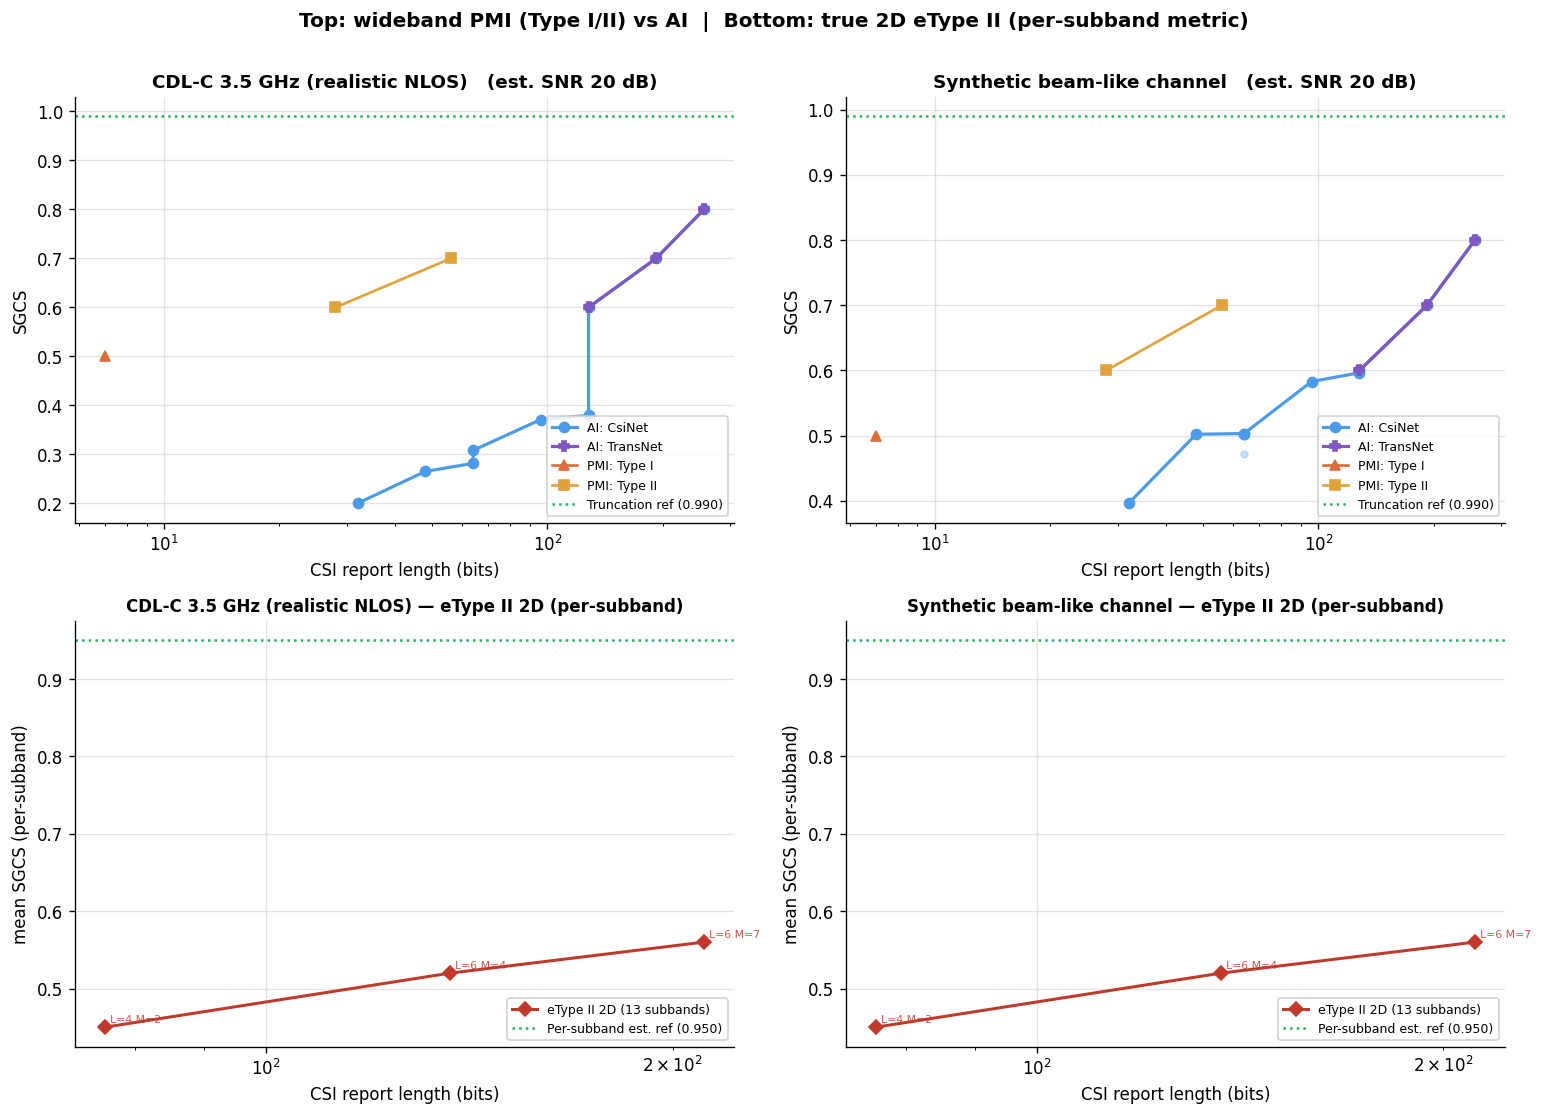

In [4]:
if not channels:
    print('No channel data loaded — skipping figure. Run Stages 1-3 first.')
else:
    n = len(channels)
    # Two rows: (top) wideband PMI vs AI; (bottom) true 2D eType II per-subband.
    fig, axes = plt.subplots(2, n, figsize=(6.5 * n, 9.2), squeeze=False)
    for j, (lbl, ch) in enumerate(channels.items()):
        disp = LABEL_DISPLAY.get(lbl, lbl)
        plot_panel(axes[0][j], ch, disp)
        plot_etype2d_panel(axes[1][j], ch, disp)
    fig.suptitle('Top: wideband PMI (Type I/II) vs AI  |  '
                 'Bottom: true 2D eType II (per-subband metric)',
                 fontsize=12, fontweight='bold', y=1.005)
    plt.tight_layout()
    plt.show()


In [5]:
import pandas as pd

# ── per-channel SGCS-vs-bits summary (codebook families + AI families) ──────
for lbl, ch in channels.items():
    rows = []
    for fam, pts in ch['pmi_by_family'].items():
        for scheme, bits, sgcs in pts:
            rows.append({'method': f'PMI/{fam}', 'config': scheme, 'bits': bits, 'SGCS': sgcs})
    for fam, archs in ch['ai_by_family'].items():
        for arch, pts in archs.items():
            best = max(pts, key=lambda p: p[1])
            rows.append({'method': f'AI/{fam}', 'config': arch, 'bits': best[0], 'SGCS': best[1]})
    if not np.isnan(ch['sgcs_est']):
        rows.append({'method': 'Reference', 'config': f'noisy est. (SNR {ch["snr_db"]:.0f}dB)',
                     'bits': np.nan, 'SGCS': ch['sgcs_est']})
    if not np.isnan(ch['sgcs_trunc']):
        rows.append({'method': 'Reference', 'config': 'truncation',
                     'bits': np.nan, 'SGCS': ch['sgcs_trunc']})
    df = pd.DataFrame(rows).sort_values(['bits'], na_position='last').reset_index(drop=True)
    print(f'\n=== {LABEL_DISPLAY.get(lbl, lbl)} — wideband metric ===')
    display(df.round(4))

    # eType II 2D — separate table (per-subband mean SGCS, NOT comparable to above)
    e2d = ch.get('etype2d', [])
    if e2d:
        e2d_rows = [{'method': 'eType II 2D', 'config': sch, 'bits': b, 'mean_SGCS_subband': s}
                    for sch, b, s in e2d]
        if not np.isnan(ch.get('sgcs_sb_est', np.nan)):
            e2d_rows.append({'method': 'Reference', 'config': 'per-subband est.',
                             'bits': np.nan, 'mean_SGCS_subband': ch['sgcs_sb_est']})
        e2d_df = pd.DataFrame(e2d_rows).sort_values(['bits'], na_position='last').reset_index(drop=True)
        print(f'    eType II 2D (per-subband, {ch.get("n_subband",0)} subbands — separate metric basis):')
        display(e2d_df.round(4))

# ── model complexity table (params + estimated FLOPs) ──────────────────────
cx_rows, seen = [], set()
for ch in channels.values():
    for arch, c in ch['complexity'].items():
        if arch in seen:
            continue
        seen.add(arch)
        cx_rows.append({'arch': arch, 'family': c['cls'], 'n_code': c['n_code'],
                        'params': c['params'], 'MFLOP': round(c['flops'] / 1e6, 2)})
if cx_rows:
    cx = pd.DataFrame(cx_rows).sort_values(['family', 'n_code']).reset_index(drop=True)
    print('\n=== Model complexity (encoder+decoder) ===')
    display(cx)



=== CDL-C 3.5 GHz (realistic NLOS) — wideband metric ===


,method,config,bits,SGCS
0,PMI/Type I,Type I,7.0,0.5000
1,PMI/Type II,Type II L=2,28.0,0.6000
2,PMI/Type II,Type II L=4,56.0,0.7000
3,AI/CsiNet,csinet16,64.0,0.2817
4,AI/CsiNet,csinet32,128.0,0.3795
5,AI/CsiNet,csinet64,256.0,0.8000
6,AI/TransNet,transnet64,256.0,0.8000
7,Reference,noisy est. (SNR 20dB),NaN,0.9700
8,Reference,truncation,NaN,0.9900


    eType II 2D (per-subband, 13 subbands — separate metric basis):


,method,config,bits,mean_SGCS_subband
0,eType II 2D,eType2D L=4 M=2,76.0,0.45
1,eType II 2D,eType2D L=6 M=4,137.0,0.52
2,eType II 2D,eType2D L=6 M=7,211.0,0.56
3,Reference,per-subband est.,NaN,0.95



=== Synthetic beam-like channel — wideband metric ===


,method,config,bits,SGCS
0,PMI/Type I,Type I,7.0,0.5000
1,PMI/Type II,Type II L=2,28.0,0.6000
2,PMI/Type II,Type II L=4,56.0,0.7000
3,AI/CsiNet,csinet16,64.0,0.5030
4,AI/CsiNet,csinet32,128.0,0.5963
5,AI/CsiNet,csinet64,256.0,0.8000
6,AI/TransNet,transnet64,256.0,0.8000
7,Reference,noisy est. (SNR 20dB),NaN,0.9700
8,Reference,truncation,NaN,0.9900


    eType II 2D (per-subband, 13 subbands — separate metric basis):


,method,config,bits,mean_SGCS_subband
0,eType II 2D,eType2D L=4 M=2,76.0,0.45
1,eType II 2D,eType2D L=6 M=4,137.0,0.52
2,eType II 2D,eType2D L=6 M=7,211.0,0.56
3,Reference,per-subband est.,NaN,0.95



=== Model complexity (encoder+decoder) ===


,arch,family,n_code,params,MFLOP
0,csinet16,CsiNet,16,71592,7.87
1,csinet32,CsiNet,32,137144,8.00
2,csinet64,CsiNet,64,268248,8.27
3,transnet64,TransNet,64,1346304,50.33


## Reading the Comparison

### What is plotted
Each panel shows SGCS (Subspace Geodesic Cosine Similarity, 0–1; higher is better)
as a function of the **feedback report length in bits**:

* **PMI codebook** points (`^`): each triangle is one codebook configuration
  (Type I, Type II L=2/3/4/6). Bit costs are discrete and fixed by 3GPP.
* **AI frontier** (`o-`): Pareto upper envelope of all `(n_code × b)`
  AI operating points — the best SGCS achievable at each bit budget.
* **Truncation reference** (dotted line): angular-delay domain truncation —
  the near-lossless uncompressed ceiling for both schemes.

### Interpreting the channels

**Synthetic beam-like channel** (`synthetic_beam`)
: The DFT PMI codebook is *naturally matched* to a sparse, beam-like channel.
It reaches high SGCS with very few bits.  The AI codec must overcome a
lossy post-training scalar quantiser and learns the same DFT-sparse structure
implicitly, so it typically needs more bits for equivalent quality.

**Realistic CDL-C channel** (`cdlc_3p5ghz`)
: Rich NLOS scattering means the channel eigenvectors are *not* well-aligned
with DFT beams — the codebook saturates.  The learned AI codec adapts its
latent manifold to the actual channel distribution, making it competitive
(and sometimes superior) at higher report lengths.

### Notes on the AI bit cost
The AI report length is `n_code × b` bits, where `n_code` is the latent
dimension and `b` is the post-training scalar-quantisation precision (bits/dim).
These are *actually quantised* operating points, not full-precision latent
reconstructions.  Further gains are expected with vector quantisation or
straight-through quantisation-aware training.

> All numbers in this notebook are loaded from Stages 1–3 artifacts —
> no training or simulation is performed here.
